In [11]:
!pip install -U ultralytics

In [12]:
from ultralytics import YOLO
import squarify
import matplotlib.pyplot as plt
import cv2
import os
import random
import pandas as pd
import matplotlib.image as mpimg
import seaborn as sns

sns.set_style('darkgrid')

%matplotlib inline

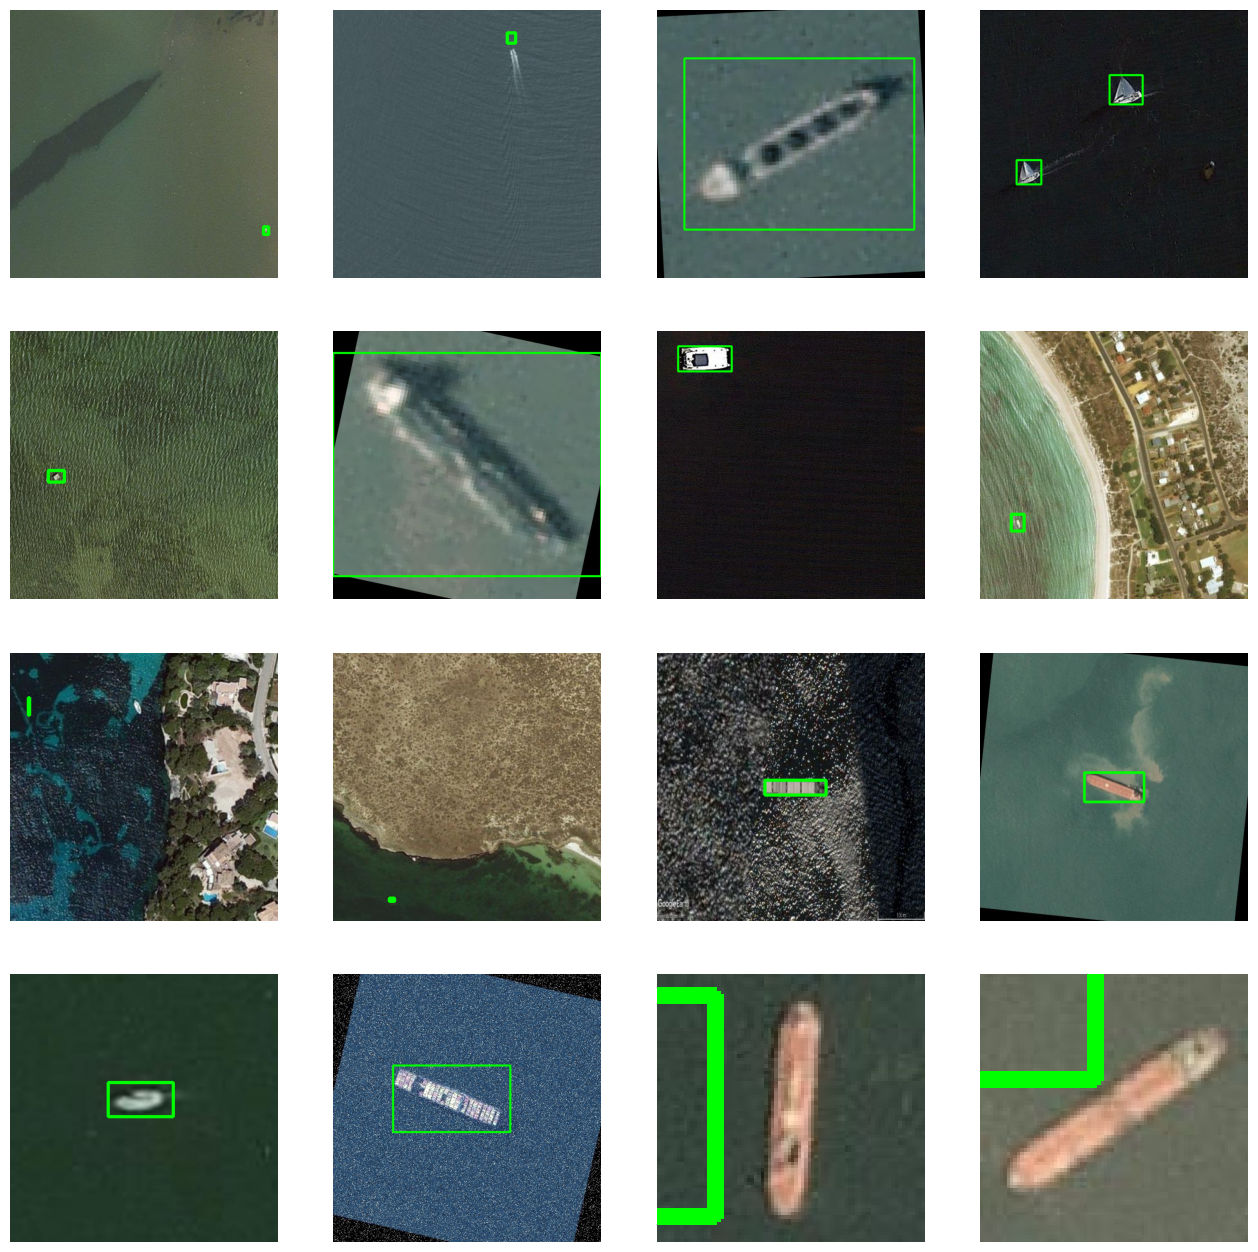

In [13]:
train_images = "/kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images/train/images"
train_labels = "/kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images/train/labels"
test_images = "/kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images/test/images"
test_labels = "/kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images/test/labels"
val_images = "/kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images/valid/images"
val_labels = "/kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images/valid/labels"
image_files = os.listdir(train_images)

# Choose 16 random image files from the list
random_images = random.sample(image_files, 16)

# Set up the plot
fig, axs = plt.subplots(4, 4, figsize=(16, 16))

# Loop over the random images and plot the object detections
for i, image_file in enumerate(random_images):
    row = i // 4
    col = i % 4
    
    # Load the image
    image_path = os.path.join(train_images, image_file)
    image = cv2.imread(image_path)

    # Load the labels for this image
    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(train_labels, label_file)
    with open(label_path, "r") as f:
        labels = f.read().strip().split("\n")
    for label in labels:
        if len(label.split()) != 5:
            continue
        class_id, x_center, y_center, width, height = map(float, label.split())
        x_min = int((x_center - width/2) * image.shape[1])
        y_min = int((y_center - height/2) * image.shape[0])
        x_max = int((x_center + width/2) * image.shape[1])
        y_max = int((y_center + height/2) * image.shape[0])
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)


    # Show the image with the object detections
    axs[row, col].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axs[row, col].axis('off')
plt.show()

In [14]:
with open("/kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images/data.yaml") as f:
    print(f.read())

train: /kaggle/input/ships-in-aerial-images/ships-aerial-images/train/images
val: /kaggle/input/ships-in-aerial-images/ships-aerial-images/valid/images
test: /kaggle/input/ships-in-aerial-images/ships-aerial-images/test/images

nc: 1
names: ['ship']


In [15]:
yaml_content = """
path: /kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images

train: train/images
val: valid/images
test: test/images

nc: 1

names:
  0: ship
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

data.yaml created successfully!


In [18]:
from ultralytics import YOLO
model = YOLO("yolo26n.pt")

# Training the model
model.train(data = "/kaggle/working/data.yaml",
            epochs = 20,
            imgsz = 640,
            seed = 42,
            batch = 64,
            workers = 4)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7addbad6bd40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [19]:
%matplotlib inline
# Loading the best performing model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

# Evaluating the model on the test dataset
metrics = model.val(conf = 0.25, split = 'test')

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 3.5±3.1 MB/s, size: 17.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images/test/labels... 1573 images, 51 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1573/1573 275.3it/s 5.7s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/siddharthkumarsah/ships-in-aerial-images/ships-aerial-images/test is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 106, len(boxes) = 2872. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a 

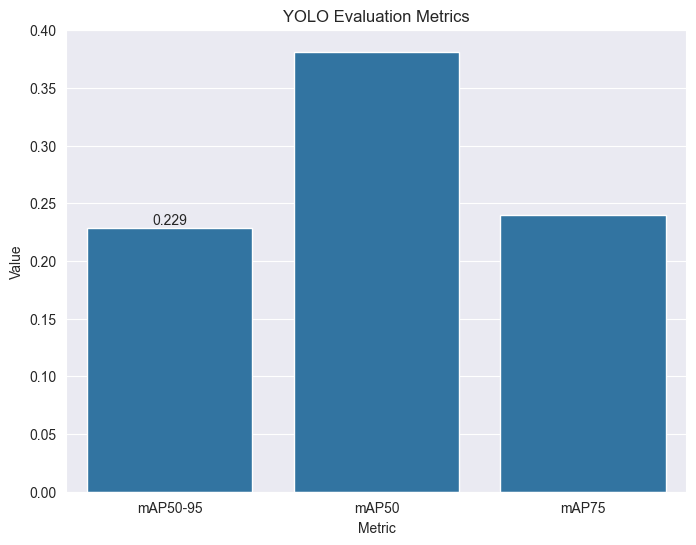

In [20]:
%matplotlib inline
# Create the barplot
ax = sns.barplot(x=['mAP50-95', 'mAP50', 'mAP75'], y=[metrics.box.map, metrics.box.map50, metrics.box.map75])

# Set the title and axis labels
ax.set_title('YOLO Evaluation Metrics')
ax.set_xlabel('Metric')
ax.set_ylabel('Value')

# Set the figure size
fig = plt.gcf()
fig.set_size_inches(8, 6)

# Add the values on top of the bars
for p in ax.patches:
    ax.annotate('{:.3f}'.format(p.get_height()), (p.get_x() + p.
get_width() / 2, p.get_height()), ha='center', va='bottom')
    plt.show()

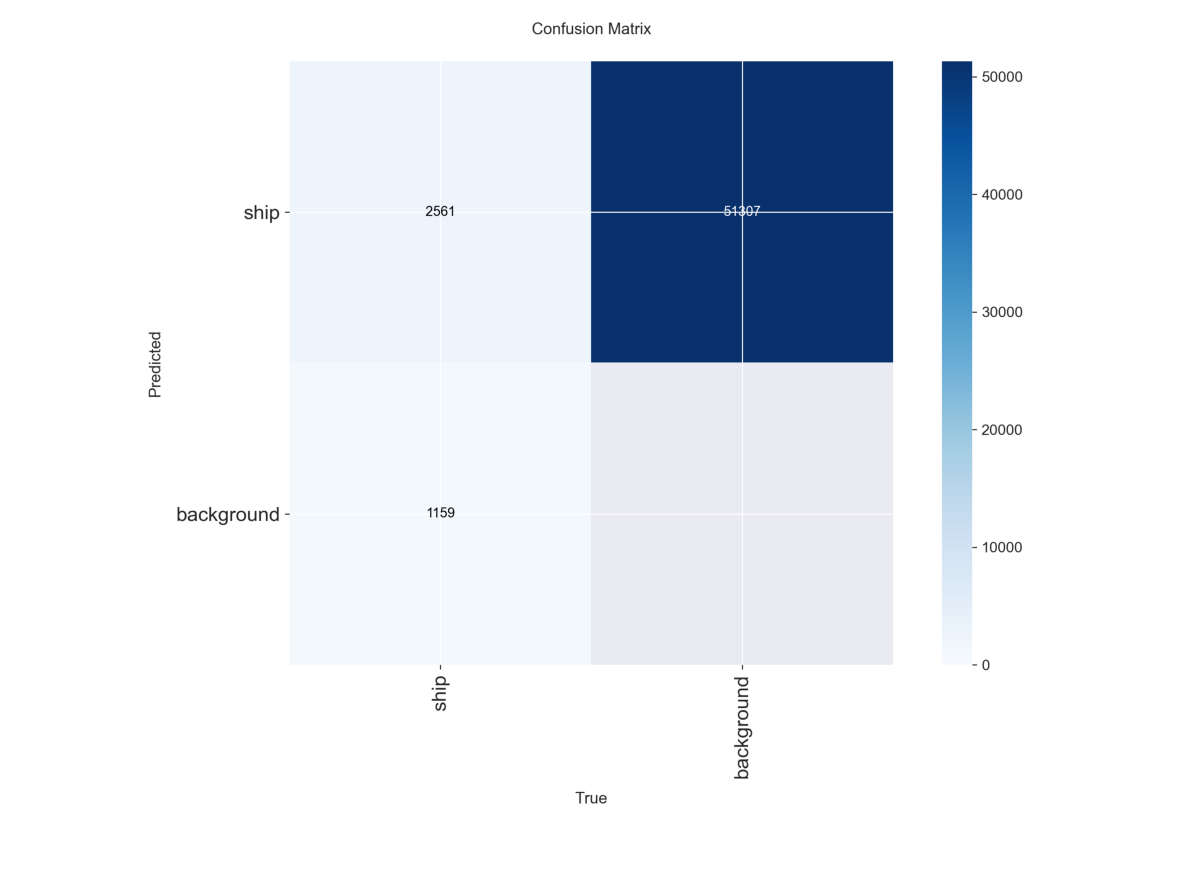

In [21]:
%matplotlib inline
# Reading the confusion matrix image file
img = mpimg.imread('/kaggle/working/runs/detect/train/confusion_matrix.png')

# Plotting the confusion matrix image
fig, ax = plt.subplots(figsize = (15, 15))

ax.imshow(img)
ax.axis('off');